<a href="https://colab.research.google.com/github/kh1z3r/chicago-food-inspections/blob/main/food_inspections.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
CSV_PATH = '/content/drive/MyDrive/AI4ALL/Food_Inspections_20260628.csv'
df = pd.read_csv(CSV_PATH, dtype={'Zip': 'string', 'License #': 'string'})
print(df.shape)
df.head()

Mounted at /content/drive
(312415, 17)


,Inspection ID,DBA Name,AKA Name,License #,Facility Type,Risk,Address,City,State,Zip,Inspection Date,Inspection Type,Results,Violations,Latitude,Longitude,Location
0,2639042,SHELL,SHELL,3090559,Grocery Store,Risk 3 (Low),9802 S HALSTED ST,CHICAGO,IL,60628,06/25/2026,License,Pass,NaN,41.715805,-87.643208,"(41.71580477012766, -87.64320825324427)"
1,2639047,JUNIOR CHEFS KITCHEN,JUNIOR CHEFS KITCHEN,3065477,Restaurant,Risk 1 (High),1061 W VAN BUREN ST,CHICAGO,IL,60607,06/25/2026,License,Pass,51. PLUMBING INSTALLED; PROPER BACKFLOW DEVICE...,41.876456,-87.654296,"(41.87645614541188, -87.65429579519606)"
2,2639049,JUNIOR CHEFS KITCHEN,JUNIOR CHEFS KITCHEN,3065478,Restaurant,Risk 1 (High),1061 W VAN BUREN ST,CHICAGO,IL,60607,06/25/2026,License,Pass,NaN,41.876456,-87.654296,"(41.87645614541188, -87.65429579519606)"
3,2638998,BREAKFAST HOUSE,BREAKFAST HOUSE,3087028,Restaurant,Risk 3 (Low),501 W DIVERSEY PKWY,CHICAGO,IL,60614,06/25/2026,License,Pass,NaN,41.932757,-87.641488,"(41.9327574222532, -87.6414877332763)"
4,2639009,TARRA,TARRA,3086370,Restaurant,Risk 3 (Low),121 W HUBBARD ST,CHICAGO,IL,60654,06/25/2026,License,Pass,NaN,41.889900,-87.632032,"(41.889900231874854, -87.63203247618843)"


In [3]:
#Target: We predict the Results column as Fail = 1 vs not-Fail = 0 (Pass and Pass w/ Conditions = 0; we drop non-decision outcomes like Out of Business and No Entry).

In [4]:
import numpy as np

# "Results" is text (Pass, Fail, ...). Convert it to a 0/1 target the model can learn.
# Normalize the text first so spacing/case differences don't create duplicate categories.
r = df["Results"].str.strip().str.upper()

# Fail = 1; Pass and Pass w/ Conditions = 0. Any other result (Out of Business, No Entry, Not Ready)
# isn't a real pass/fail decision, so map it to NaN here and drop it on the next line.
fail_map = {"FAIL": 1, "PASS": 0, "PASS W/ CONDITIONS": 0}
df["y"] = r.map(fail_map)

before = len(df)
df = df[df["y"].notna()].copy()      # keep only genuine pass/fail rows
df["y"] = df["y"].astype(int)

print(f"Rows: {before} -> {len(df)}")
print(f"Fail rate: {df['y'].mean():.1%}")

Rows: 312415 -> 268226
Fail rate: 22.4%


In [5]:
# Use only information available BEFORE an inspection. We deliberately exclude the Violations column,
# because it's recorded during the inspection - feeding it in would leak the answer to the model.

# Facility Type has 527 messy values. Keep the 15 most common, lump the rest into "OTHER",
# and fill blanks with the most common value.
ft = df["Facility Type"].astype("string").str.strip().str.upper()
ft = ft.fillna(ft.mode(dropna=True)[0])
top15 = ft.value_counts().head(15).index
df["FacilityType_g"] = ft.where(ft.isin(top15), "OTHER")

# Inspection Type has 111 values. Collapse them into a few families. This feature matters because
# Complaint and Re-Inspection visits target already-flagged places, so it lets the model tell
# "inspected more often" apart from "actually worse".
it = df["Inspection Type"].astype("string").str.strip().str.upper().fillna("OTHER")
def fam(s):
    if "RE-INSPECTION" in s or "REINSPECTION" in s: return "Re-Inspection"
    if "COMPLAINT" in s: return "Complaint"
    if "CANVASS" in s:   return "Canvass"
    if "LICENSE" in s:   return "License"
    return "Other"
df["InspType_g"] = it.map(fam)

# Risk has three real levels plus a few blank / "All" rows. Drop those rows.
rk = df["Risk"].astype("string").str.strip()
valid_risk = ["Risk 1 (High)", "Risk 2 (Medium)", "Risk 3 (Low)"]
df = df[rk.isin(valid_risk)].copy()
df["Risk_g"] = df["Risk"].str.strip()

# Zip is the location feature. Drop blank zips and keep it as text - a ZIP is a category,
# not a quantity (60614 isn't "greater than" 60612).
df = df[df["Zip"].notna() & (df["Zip"].str.strip() != "")].copy()
df["Zip"] = df["Zip"].str.strip()

# License # identifies the establishment; we'll use it to group the split. Drop blank/0 licenses,
# since a missing group would silently merge many unrelated establishments into one.
lic = df["License #"].fillna("0").str.strip()
df = df[(lic != "") & (lic != "0")].copy()
df["lic"] = df["License #"].str.strip()

print("Rows after cleaning:", len(df), "| distinct licenses:", df["lic"].nunique())
print(df["InspType_g"].value_counts())

Rows after cleaning: 267477 | distinct licenses: 43356
InspType_g
Canvass          130539
Re-Inspection     59205
License           37265
Complaint         36946
Other              3522
Name: count, dtype: int64


In [6]:
from sklearn.model_selection import GroupShuffleSplit

# The same restaurant appears many times. If some of its inspections go to training and others to
# testing, the model can memorize that specific place and post an inflated score. GroupShuffleSplit
# keeps every inspection of one license entirely in train OR test - never both.
FEATURES = ["FacilityType_g", "Risk_g", "InspType_g", "Zip"]
X = df[FEATURES]
y = df["y"].values
groups = df["lic"].values                 # group = the establishment's license number

# random_state=42 fixes the split so every teammate gets identical train/test rows.
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
Xtr, Xte = X.iloc[train_idx], X.iloc[test_idx]
ytr, yte = y[train_idx], y[test_idx]

# Sanity check: no license should appear in both sets.
overlap = set(groups[train_idx]) & set(groups[test_idx])
print(f"Train {len(Xtr)} | Test {len(Xte)} | overlapping licenses: {len(overlap)} (must be 0)")

Train 213769 | Test 53708 | overlapping licenses: 0 (must be 0)


In [7]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, precision_score, f1_score, confusion_matrix

# The features are text categories, so we one-hot encode them (one 0/1 column per category).
# Keeping the encoder inside a Pipeline means it's fit on the training data only, then applied to test.
def make_pipe(model, feats):
    enc = ColumnTransformer([("oh", OneHotEncoder(handle_unknown="ignore"), feats)])
    return Pipeline([("enc", enc), ("model", model)])

# We score on RECALL of failures (the share of real fails we catch), not overall accuracy: since ~78%
# of inspections pass, a model that always says "Pass" is 78% accurate yet catches nothing useful.
def report(name, ypred):
    print(f"\n[{name}]  recall={recall_score(yte, ypred, zero_division=0):.3f} "
          f"precision={precision_score(yte, ypred, zero_division=0):.3f} "
          f"F1={f1_score(yte, ypred, zero_division=0):.3f}")
    print("confusion [[TN FP][FN TP]]:\n", confusion_matrix(yte, ypred))

# Baseline: always predict Pass. Catches zero failures by design - the bar our models must clear.
report("Naive baseline (always Pass)", np.zeros_like(yte))

# Logistic regression: simple and explainable. class_weight="balanced" weights the rare failures
# more heavily so the model doesn't just ignore them.
logreg = make_pipe(LogisticRegression(class_weight="balanced", max_iter=1000), FEATURES)
logreg.fit(Xtr, ytr)
report("Logistic Regression", logreg.predict(Xte))

# Random forest: many decision trees combined - usually more accurate and can rank feature importance.
# n_estimators=150 runs in ~1-2 min on Colab; raise to 300 for the final version.
rf = make_pipe(RandomForestClassifier(class_weight="balanced", n_estimators=150,
                                      random_state=42, n_jobs=-1), FEATURES)
rf.fit(Xtr, ytr)
report("Random Forest", rf.predict(Xte))


[Naive baseline (always Pass)]  recall=0.000 precision=0.000 F1=0.000
confusion [[TN FP][FN TP]]:
 [[41621     0]
 [12087     0]]

[Logistic Regression]  recall=0.698 precision=0.296 F1=0.415
confusion [[TN FP][FN TP]]:
 [[21520 20101]
 [ 3649  8438]]

[Random Forest]  recall=0.669 precision=0.304 F1=0.418
confusion [[TN FP][FN TP]]:
 [[23084 18537]
 [ 3999  8088]]


In [8]:
# Use only information available BEFORE an inspection. We deliberately exclude the Violations column,
# because it's recorded during the inspection - feeding it in would leak the answer to the model.

# Facility Type has 527 messy values. Keep the 15 most common, lump the rest into "OTHER",
# and fill blanks with the most common value.
ft = df["Facility Type"].astype("string").str.strip().str.upper()
ft = ft.fillna(ft.mode(dropna=True)[0])
top15 = ft.value_counts().head(15).index
df["FacilityType_g"] = ft.where(ft.isin(top15), "OTHER")

# Inspection Type has 111 values. Collapse them into a few families. This feature matters because
# Complaint and Re-Inspection visits target already-flagged places, so it lets the model tell
# "inspected more often" apart from "actually worse".
it = df["Inspection Type"].astype("string").str.strip().str.upper().fillna("OTHER")
def fam(s):
    if "RE-INSPECTION" in s or "REINSPECTION" in s: return "Re-Inspection"
    if "COMPLAINT" in s: return "Complaint"
    if "CANVASS" in s:   return "Canvass"
    if "LICENSE" in s:   return "License"
    return "Other"
df["InspType_g"] = it.map(fam)

# Risk has three real levels plus a few blank / "All" rows. Drop those rows.
rk = df["Risk"].astype("string").str.strip()
valid_risk = ["Risk 1 (High)", "Risk 2 (Medium)", "Risk 3 (Low)"]
df = df[rk.isin(valid_risk)].copy()
df["Risk_g"] = df["Risk"].str.strip()

# Zip is the location feature. Drop blank zips and keep it as text - a ZIP is a category,
# not a quantity (60614 isn't "greater than" 60612).
df = df[df["Zip"].notna() & (df["Zip"].str.strip() != "")].copy()
df["Zip"] = df["Zip"].str.strip()

# License # identifies the establishment; we'll use it to group the split. Drop blank/0 licenses,
# since a missing group would silently merge many unrelated establishments into one.
lic = df["License #"].fillna("0").str.strip()
df = df[(lic != "") & (lic != "0")].copy()
df["lic"] = df["License #"].str.strip()

print("Rows after cleaning:", len(df), "| distinct licenses:", df["lic"].nunique())
print(df["InspType_g"].value_counts())

Rows after cleaning: 267477 | distinct licenses: 43356
InspType_g
Canvass          130539
Re-Inspection     59205
License           37265
Complaint         36946
Other              3522
Name: count, dtype: int64


In [9]:
from sklearn.model_selection import GroupShuffleSplit

# The same restaurant appears many times. If some of its inspections go to training and others to
# testing, the model can memorize that specific place and post an inflated score. GroupShuffleSplit
# keeps every inspection of one license entirely in train OR test - never both.
FEATURES = ["FacilityType_g", "Risk_g", "InspType_g", "Zip"]
X = df[FEATURES]
y = df["y"].values
groups = df["lic"].values                 # group = the establishment's license number

# random_state=42 fixes the split so every teammate gets identical train/test rows.
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
Xtr, Xte = X.iloc[train_idx], X.iloc[test_idx]
ytr, yte = y[train_idx], y[test_idx]

# Sanity check: no license should appear in both sets.
overlap = set(groups[train_idx]) & set(groups[test_idx])
print(f"Train {len(Xtr)} | Test {len(Xte)} | overlapping licenses: {len(overlap)} (must be 0)")

Train 213769 | Test 53708 | overlapping licenses: 0 (must be 0)


In [10]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, precision_score, f1_score, confusion_matrix

# The features are text categories, so we one-hot encode them (one 0/1 column per category).
# Keeping the encoder inside a Pipeline means it's fit on the training data only, then applied to test.
def make_pipe(model, feats):
    enc = ColumnTransformer([("oh", OneHotEncoder(handle_unknown="ignore"), feats)])
    return Pipeline([("enc", enc), ("model", model)])

# We score on RECALL of failures (the share of real fails we catch), not overall accuracy: since ~78%
# of inspections pass, a model that always says "Pass" is 78% accurate yet catches nothing useful.
def report(name, ypred):
    print(f"\n[{name}]  recall={recall_score(yte, ypred, zero_division=0):.3f} "
          f"precision={precision_score(yte, ypred, zero_division=0):.3f} "
          f"F1={f1_score(yte, ypred, zero_division=0):.3f}")
    print("confusion [[TN FP][FN TP]]:\n", confusion_matrix(yte, ypred))

# Baseline: always predict Pass. Catches zero failures by design - the bar our models must clear.
report("Naive baseline (always Pass)", np.zeros_like(yte))

# Logistic regression: simple and explainable. class_weight="balanced" weights the rare failures
# more heavily so the model doesn't just ignore them.
logreg = make_pipe(LogisticRegression(class_weight="balanced", max_iter=1000), FEATURES)
logreg.fit(Xtr, ytr)
report("Logistic Regression", logreg.predict(Xte))

# Random forest: many decision trees combined - usually more accurate and can rank feature importance.
# n_estimators=150 runs in ~1-2 min on Colab; raise to 300 for the final version.
rf = make_pipe(RandomForestClassifier(class_weight="balanced", n_estimators=150,
                                      random_state=42, n_jobs=-1), FEATURES)
rf.fit(Xtr, ytr)
report("Random Forest", rf.predict(Xte))


[Naive baseline (always Pass)]  recall=0.000 precision=0.000 F1=0.000
confusion [[TN FP][FN TP]]:
 [[41621     0]
 [12087     0]]

[Logistic Regression]  recall=0.698 precision=0.296 F1=0.415
confusion [[TN FP][FN TP]]:
 [[21520 20101]
 [ 3649  8438]]

[Random Forest]  recall=0.669 precision=0.304 F1=0.418
confusion [[TN FP][FN TP]]:
 [[23084 18537]
 [ 3999  8088]]


Drop in Fail-recall when shuffled (higher = more important):
InspType_g        0.1269
Zip               0.0778
FacilityType_g    0.0689
Risk_g            0.0361


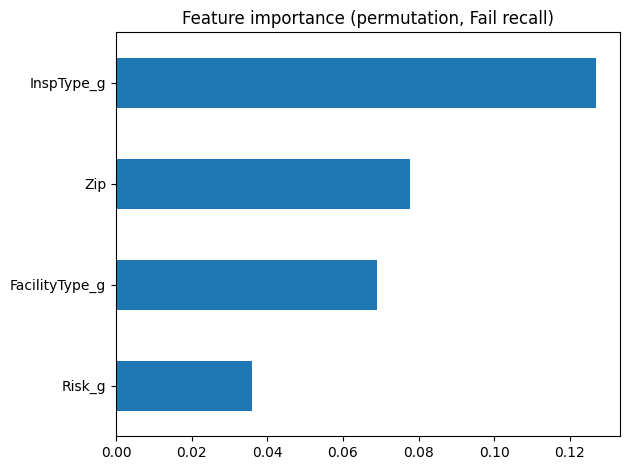

In [11]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# Permutation importance shows how much the model leans on each feature: shuffle one feature's values
# in the test set and measure how far Fail-recall drops. A bigger drop means that feature mattered more.
# We shuffle the original column (before encoding), so each feature - including all the ZIP columns
# together - is measured as one group. We sample 15k test rows to keep it fast.
samp = min(15000, len(Xte))
si = np.random.RandomState(42).choice(len(Xte), samp, replace=False)
pi = permutation_importance(rf, Xte.iloc[si], yte[si], scoring="recall",
                            n_repeats=5, random_state=42, n_jobs=-1)

imp = pd.Series(pi.importances_mean, index=FEATURES).sort_values(ascending=False)
print("Drop in Fail-recall when shuffled (higher = more important):")
print(imp.round(4).to_string())

imp.sort_values().plot.barh()
plt.title("Feature importance (permutation, Fail recall)")
plt.tight_layout(); plt.show()